### Annual and monthly climatologies of key variables 
### Results: Section 1b

In [1]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import gc
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Band definitions used
- North: 5-12**N** / 10-31**E**
- Equatorial: 5**S**-5**N** / 8-29**E**
- South: 15-5**S** / 12-31**E**

### Onset-Cessation
**Northern Band**
- onset = 125, cessation = 297
- onset = start-May, cessation = end-October
- season length 172

**Equatorial Band**
- onset = 62, cessation = 142
- onset = start-March, cessation = end-May
- season length 80
-
- onset = 247, cessation = 341
- onset = start-September, cessation = mid-December
- season length 94

**Southern Band**
- onset = 290, cessation = 111
- onset = Mid-October, cessation = near-end April
- season length 186


In [2]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/F4R_data/"
dataf = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_fapar/"
datal = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_lai/"
datat = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_tropomi/"
datam = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_modis/"
dataclass = "/Volumes/New_5TB/ESA_F4R/landcover_classification/"

bandname = 'Equatorial Band'
band = 'EQ'
band_lats=[-5,5]
band_lons=[8,29]
dates = [[2,32],[32,62],[62,92],[187,217],[217,247],[247,277]] #EQ
#dates = [[65,95],[95,125],[125,155]] #N
#dates = [[230,260],[260,290],[290,320]] #S
timing = ['Pre-Onset','Onset','Start of Season']

In [3]:
evap = xr.open_mfdataset(datam+'modis_*_10day_reg_regrid.nc')*0.1/8.0
t2m = xr.open_mfdataset(datac+'era5_10day_reg_regrid.nc')-273.0 
fapar = xr.open_mfdataset(dataf+'fapar_*_reg_regrid.nc')
precip = xr.open_mfdataset(datac+'chirps_10day_reg_regrid.nc') 
lai = xr.open_mfdataset(datal+'lai_*_reg_regrid.nc') 
sif = xr.open_mfdataset(datac+'sif_10day_reg_regrid.nc') 
hdo = xr.open_mfdataset(datac+'hdo_10day_reg_regrid.nc') 
tropess = xr.open_mfdataset('/Users/ellendyer/Documents/GitHub/F4R_data/tropess_gridded_caf_lowmid.nc') 
tropess = tropess.interp(lat=np.arange(tropess.coords["lat"].min().values,tropess.coords["lat"].max().values,0.25), lon=np.arange(tropess.coords["lon"].min().values,tropess.coords["lon"].max().values,0.25), method="linear")

In [4]:
evap = evap.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
t2m = t2m.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
fapar = fapar.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
precip = precip.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
lai = lai.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
sif = sif.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
hdo = hdo.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
tropess = tropess.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)

Equatorial Band


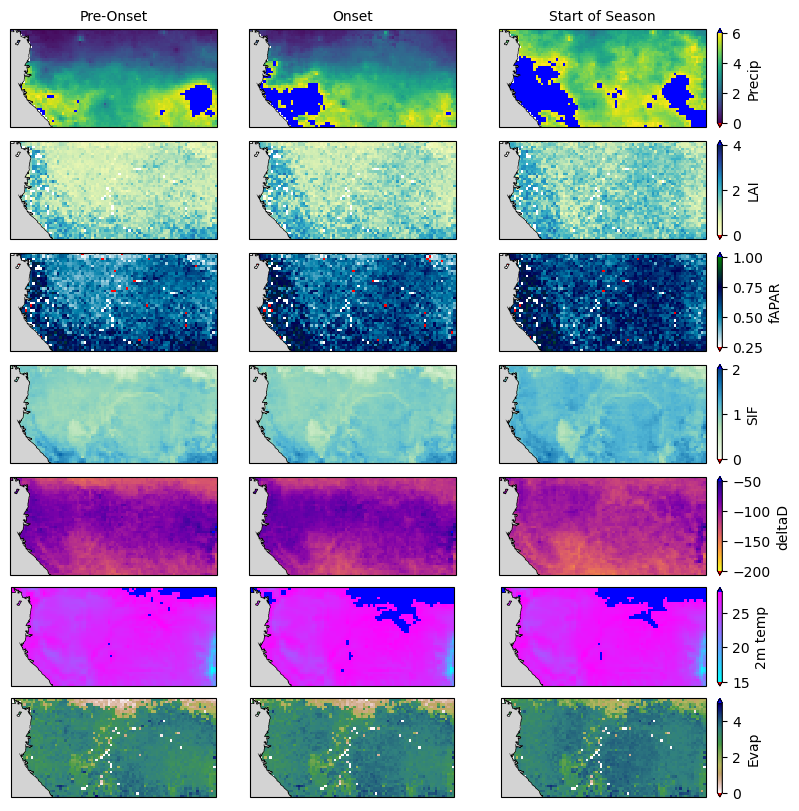

<Figure size 640x480 with 0 Axes>

In [11]:
ncols=3
nrows=7
h = nrows
w = ncols

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(8,8))
axs=axs.flatten()
over = 'blue'
under = 'red'

for i in range(0,3):
    cmap=plt.cm.viridis
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    cst=precip['precip'].sel(time=(precip.time.dt.dayofyear.isin(np.arange(dates[i][0],dates[i][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                        vmin=0, vmax=6,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        add_labels=True,
                        transform = ccrs.PlateCarree())
    axs[i].set_title(timing[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='Precip',
                        shrink=1.0,extend="both",fraction=0.2)

for i in range(3,6):
    cmap=plt.cm.YlGnBu
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    cst=lai['LAI'].sel(time=(lai.time.dt.dayofyear.isin(np.arange(dates[i-3][0],dates[i-3][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                        vmin=0, vmax=4,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('LAI',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='LAI',
                        shrink=1.0,extend="both",fraction=0.2)

for i in range(6,9):
    cmap=plt.cm.ocean_r
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    cst=fapar['fAPAR'].sel(time=(fapar.time.dt.dayofyear.isin(np.arange(dates[i-6][0],dates[i-6][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                        vmin=0.25, vmax=1.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('fAPAR',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='fAPAR',
                        shrink=1.0,extend="both",fraction=0.2)

for i in range(9,12):
    cmap=plt.cm.GnBu
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    cst=sif['SIF'].sel(time=(sif.time.dt.dayofyear.isin(np.arange(dates[i-9][0],dates[i-9][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                        vmin=0, vmax=2,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('deltaD',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='SIF',
                        shrink=1.0,extend="both",fraction=0.2)

for i in range(12,15):
    cmap=plt.cm.plasma_r
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    cst=hdo['deltaD'].sel(time=(hdo.time.dt.dayofyear.isin(np.arange(dates[i-12][0],dates[i-12][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                        vmin=-200, vmax=-50.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('deltaD',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='deltaD',
                        shrink=1.0,extend="both",fraction=0.4)

for i in range(15,18):
    cmap=plt.cm.cool
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    cst=t2m['t2m'].sel(time=(t2m.time.dt.dayofyear.isin(np.arange(dates[i-15][0],dates[i-15][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                        vmin=15, vmax=28.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('deltaD',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='2m temp',
                        shrink=1.0,extend="both",fraction=0.4)

for i in range(18,21):
    cmap=plt.cm.gist_earth_r
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    cst=evap['ET_500m'].sel(time=(evap.time.dt.dayofyear.isin(np.arange(dates[i-18][0],dates[i-18][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                        vmin=0, vmax=5.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('deltaD',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='Evap',
                        shrink=1.0,extend="both",fraction=0.4)

fig.subplots_adjust(hspace=0.0,wspace=0.0)
print(bandname)
#plt.suptitle(bandname, fontsize=10)
plt.savefig(datap+'onset_rel_seas1_'+band+'.png',bbox_inches='tight')
plt.show()
plt.clf()

Equatorial Band


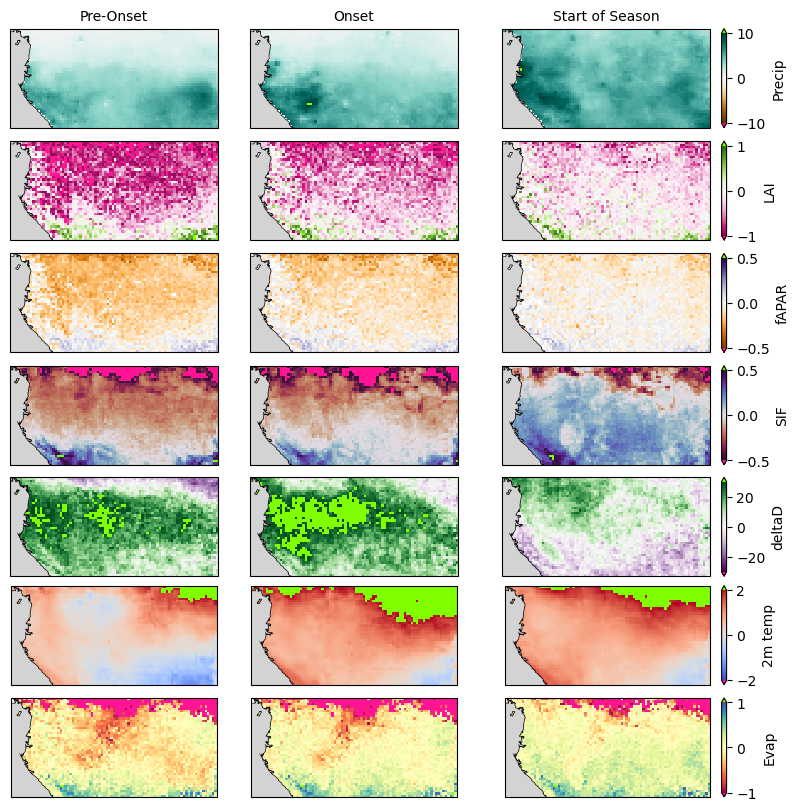

<Figure size 640x480 with 0 Axes>

In [6]:
ncols=3
nrows=7
h = nrows
w = ncols

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(8,8))
axs=axs.flatten()
over = 'chartreuse'
under = 'deeppink' 

for i in range(0,3):
    cmap=plt.cm.BrBG
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    cst=precip['precip'].sel(time=(precip.time.dt.dayofyear.isin(np.arange(dates[i][0],dates[i][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                        vmin=-10, vmax=10,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        add_labels=True,
                        transform = ccrs.PlateCarree())
    axs[i].set_title(timing[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='Precip',
                        shrink=1.0,extend="both",fraction=0.2)

for i in range(3,6):
    cmap=plt.cm.PiYG
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    pltv = lai['LAI'].sel(time=(lai.time.dt.dayofyear.isin(np.arange(dates[i-3][0],dates[i-3][1]+1))), drop=True).mean('time')-lai['LAI'].mean('time') 
    cst=pltv.plot.pcolormesh(ax=axs[i],
                        vmin=-1, vmax=1,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('LAI',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='LAI',
                        shrink=1.0,extend="both",fraction=0.2)

for i in range(6,9):
    cmap=plt.cm.PuOr
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    pltv = fapar['fAPAR'].sel(time=(fapar.time.dt.dayofyear.isin(np.arange(dates[i-6][0],dates[i-6][1]+1))), drop=True).mean('time')-fapar['fAPAR'].mean('time')
    cst=pltv.plot.pcolormesh(ax=axs[i],
                        vmin=-0.5, vmax=0.5,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('fAPAR',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='fAPAR',
                        shrink=1.0,extend="both",fraction=0.2)


for i in range(9,12):
    cmap=plt.cm.twilight_shifted_r
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    pltv = sif['SIF'].sel(time=(sif.time.dt.dayofyear.isin(np.arange(dates[i-9][0],dates[i-9][1]+1))), drop=True).mean('time')-sif['SIF'].mean('time')
    cst=pltv.plot.pcolormesh(ax=axs[i],
                        vmin=-0.5, vmax=0.5,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('SIF',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='SIF',
                        shrink=1.0,extend="both",fraction=0.2)

for i in range(12,15):
    cmap=plt.cm.PRGn
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    pltv = hdo['deltaD'].sel(time=(hdo.time.dt.dayofyear.isin(np.arange(dates[i-12][0],dates[i-12][1]+1))), drop=True).mean('time')-hdo['deltaD'].mean('time')
    cst=pltv.plot.pcolormesh(ax=axs[i],
                        vmin=-30, vmax=30,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('deltaD',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='deltaD',
                        shrink=1.0,extend="both",fraction=0.4)

for i in range(15,18):
    cmap=plt.cm.coolwarm
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    pltv = t2m['t2m'].sel(time=(t2m.time.dt.dayofyear.isin(np.arange(dates[i-15][0],dates[i-15][1]+1))), drop=True).mean('time')-t2m['t2m'].mean('time')
    cst=pltv.plot.pcolormesh(ax=axs[i],
                        vmin=-2, vmax=2,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('deltaD',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='2m temp',
                        shrink=1.0,extend="both",fraction=0.4)

for i in range(18,21):
    cmap=plt.cm.Spectral
    cmap.set_extremes(over=over)
    cmap.set_extremes(under=under)
    pltv = evap['ET_500m'].sel(time=(evap.time.dt.dayofyear.isin(np.arange(dates[i-18][0],dates[i-18][1]+1))), drop=True).mean('time')-evap['ET_500m'].mean('time')
    cst=pltv.plot.pcolormesh(ax=axs[i],
                        vmin=-1, vmax=1,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        transform = ccrs.PlateCarree())
    #axs[i].set_title('deltaD',fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='Evap',
                        shrink=1.0,extend="both",fraction=0.4)

fig.subplots_adjust(hspace=0.0,wspace=0.0)
print(bandname)
#plt.suptitle(bandname, fontsize=10)
plt.savefig(datap+'onset_rel_seas1_anom_'+band+'.png',bbox_inches='tight')
plt.show()
plt.clf()

Equatorial Band


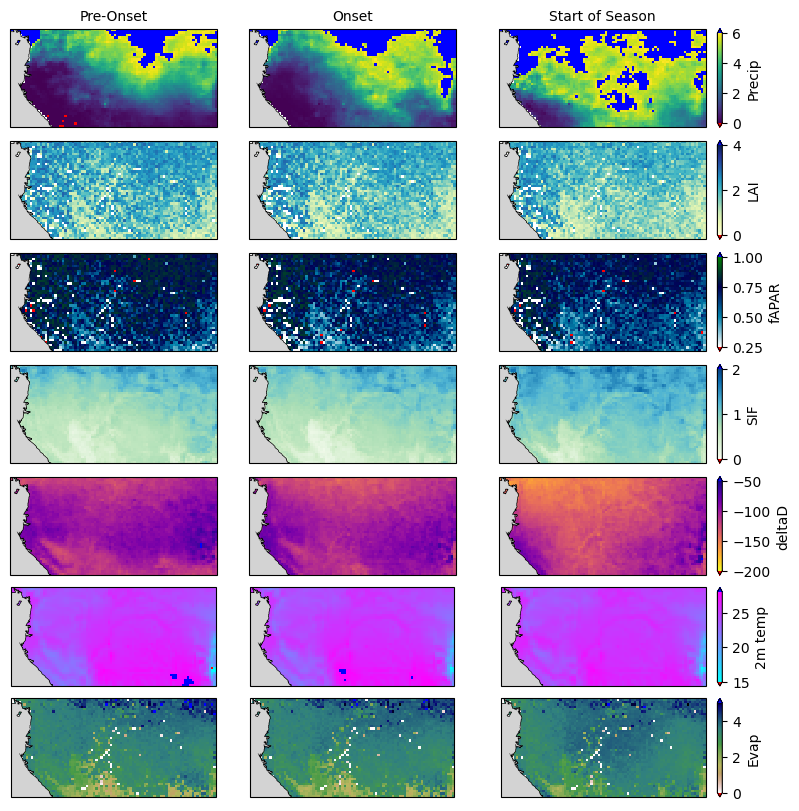

<Figure size 640x480 with 0 Axes>

In [10]:
if len(dates)>3:
    ncols=3
    nrows=7
    h = nrows
    w = ncols
    
    fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                                subplot_kw={'projection': ccrs.PlateCarree()},
                                gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                                layout="constrained",
                                figsize=(8,8))
    axs=axs.flatten()
    over = 'blue'
    under = 'red'
    
    for i in range(0,3):
        cmap=plt.cm.viridis
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        cst=precip['precip'].sel(time=(precip.time.dt.dayofyear.isin(np.arange(dates[3+i][0],dates[3+i][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                            vmin=0, vmax=6,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            add_labels=True,
                            transform = ccrs.PlateCarree())
        axs[i].set_title(timing[i],fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='Precip',
                            shrink=1.0,extend="both",fraction=0.2)
    
    for i in range(3,6):
        cmap=plt.cm.YlGnBu
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        cst=lai['LAI'].sel(time=(lai.time.dt.dayofyear.isin(np.arange(dates[3+i-3][0],dates[3+i-3][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                            vmin=0, vmax=4,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('LAI',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='LAI',
                            shrink=1.0,extend="both",fraction=0.2)
    
    for i in range(6,9):
        cmap=plt.cm.ocean_r
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        cst=fapar['fAPAR'].sel(time=(fapar.time.dt.dayofyear.isin(np.arange(dates[3+i-6][0],dates[3+i-6][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                            vmin=0.25, vmax=1.0,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('fAPAR',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='fAPAR',
                            shrink=1.0,extend="both",fraction=0.2)
    
    for i in range(9,12):
        cmap=plt.cm.GnBu
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        cst=sif['SIF'].sel(time=(sif.time.dt.dayofyear.isin(np.arange(dates[3+i-9][0],dates[3+i-9][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                            vmin=0, vmax=2,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('deltaD',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='SIF',
                            shrink=1.0,extend="both",fraction=0.2)
    
    for i in range(12,15):
        cmap=plt.cm.plasma_r
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        cst=hdo['deltaD'].sel(time=(hdo.time.dt.dayofyear.isin(np.arange(dates[3+i-12][0],dates[3+i-12][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                            vmin=-200, vmax=-50.0,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('deltaD',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='deltaD',
                            shrink=1.0,extend="both",fraction=0.4)
    
    for i in range(15,18):
        cmap=plt.cm.cool
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        cst=t2m['t2m'].sel(time=(t2m.time.dt.dayofyear.isin(np.arange(dates[3+i-15][0],dates[3+i-15][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                            vmin=15, vmax=28.0,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('deltaD',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='2m temp',
                            shrink=1.0,extend="both",fraction=0.4)
    
    for i in range(18,21):
        cmap=plt.cm.gist_earth_r
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        cst=evap['ET_500m'].sel(time=(evap.time.dt.dayofyear.isin(np.arange(dates[3+i-18][0],dates[3+i-18][1]+1))), drop=True).mean('time').plot.pcolormesh(ax=axs[i],
                            vmin=0, vmax=5.0,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('deltaD',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='Evap',
                            shrink=1.0,extend="both",fraction=0.4)

    
    fig.subplots_adjust(hspace=0.0,wspace=0.0)
    print(bandname)
    #plt.suptitle(bandname, fontsize=10)
    plt.savefig(datap+'onset_rel_seas2_'+band+'.png',bbox_inches='tight')
    plt.show()
    plt.clf()
    

Equatorial Band


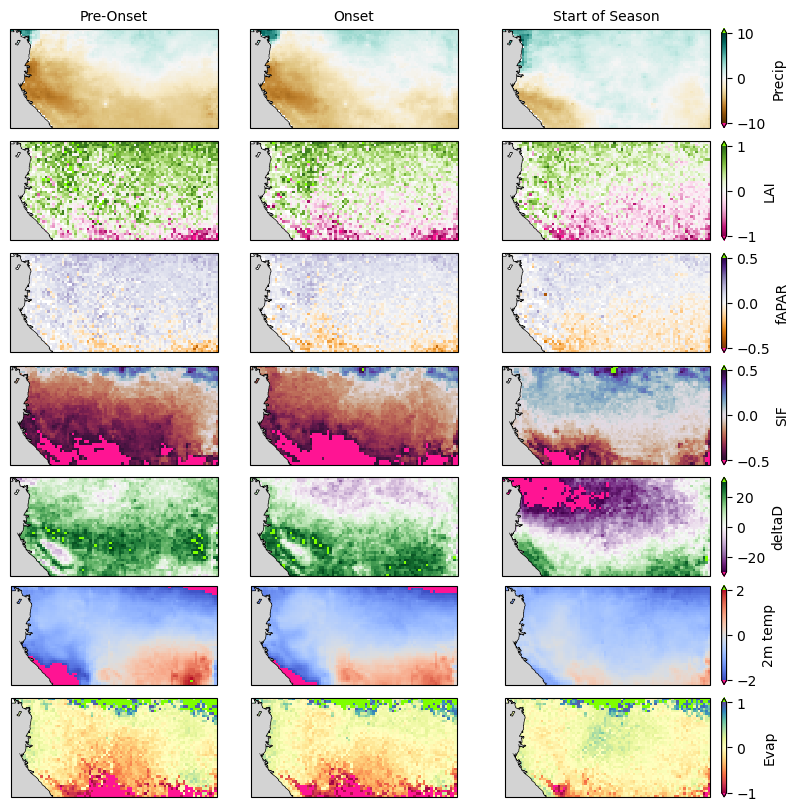

<Figure size 640x480 with 0 Axes>

In [8]:
if len(dates)>3:
    ncols=3
    nrows=7
    h = nrows
    w = ncols
    
    fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                                subplot_kw={'projection': ccrs.PlateCarree()},
                                gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                                layout="constrained",
                                figsize=(8,8))
    axs=axs.flatten()
    over = 'chartreuse'
    under = 'deeppink' 
    
    for i in range(0,3):
        cmap=plt.cm.BrBG
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        pltv = precip['precip'].sel(time=(precip.time.dt.dayofyear.isin(np.arange(dates[3+i][0],dates[3+i][1]))), drop=True).mean('time')-precip['precip'].mean('time')
        cst=pltv.plot.pcolormesh(ax=axs[i],
                            vmin=-10, vmax=10,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            add_labels=True,
                            transform = ccrs.PlateCarree())
        axs[i].set_title(timing[i],fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='Precip',
                            shrink=1.0,extend="both",fraction=0.2)
    
    for i in range(3,6):
        cmap=plt.cm.PiYG
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        pltv = lai['LAI'].sel(time=(lai.time.dt.dayofyear.isin(np.arange(dates[3+i-3][0],dates[3+i-3][1]))), drop=True).mean('time')-lai['LAI'].mean('time')
        cst=pltv.plot.pcolormesh(ax=axs[i],
                            vmin=-1, vmax=1,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('LAI',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='LAI',
                            shrink=1.0,extend="both",fraction=0.2)
    
    for i in range(6,9):
        cmap=plt.cm.PuOr
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        pltv = fapar['fAPAR'].sel(time=(fapar.time.dt.dayofyear.isin(np.arange(dates[3+i-6][0],dates[3+i-6][1]))), drop=True).mean('time')-fapar['fAPAR'].mean('time')
        cst=pltv.plot.pcolormesh(ax=axs[i],
                            vmin=-0.5, vmax=0.5,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('fAPAR',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='fAPAR',
                            shrink=1.0,extend="both",fraction=0.2)
    
    
    
    for i in range(9,12):
        cmap=plt.cm.twilight_shifted_r
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        pltv = sif['SIF'].sel(time=(sif.time.dt.dayofyear.isin(np.arange(dates[3+i-9][0],dates[3+i-9][1]))), drop=True).mean('time')-sif['SIF'].mean('time')
        cst=pltv.plot.pcolormesh(ax=axs[i],
                            vmin=-0.5, vmax=0.5,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('SIF',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='SIF',
                            shrink=1.0,extend="both",fraction=0.2)
    
    for i in range(12,15):
        cmap=plt.cm.PRGn
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        pltv = hdo['deltaD'].sel(time=(hdo.time.dt.dayofyear.isin(np.arange(dates[3+i-12][0],dates[3+i-12][1]))), drop=True).mean('time')-hdo['deltaD'].mean('time')
        cst=pltv.plot.pcolormesh(ax=axs[i],
                            vmin=-30, vmax=30,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('deltaD',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='deltaD',
                            shrink=1.0,extend="both",fraction=0.4)
        
    for i in range(15,18):
        cmap=plt.cm.coolwarm
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        pltv = t2m['t2m'].sel(time=(t2m.time.dt.dayofyear.isin(np.arange(dates[3+i-15][0],dates[3+i-15][1]+1))), drop=True).mean('time')-t2m['t2m'].mean('time')
        cst=pltv.plot.pcolormesh(ax=axs[i],
                            vmin=-2, vmax=2,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('deltaD',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='2m temp',
                            shrink=1.0,extend="both",fraction=0.4)
    
    for i in range(18,21):
        cmap=plt.cm.Spectral
        cmap.set_extremes(over=over)
        cmap.set_extremes(under=under)
        pltv = evap['ET_500m'].sel(time=(evap.time.dt.dayofyear.isin(np.arange(dates[3+i-18][0],dates[3+i-18][1]+1))), drop=True).mean('time')-evap['ET_500m'].mean('time')
        cst=pltv.plot.pcolormesh(ax=axs[i],
                            vmin=-1, vmax=1,
                            cmap=cmap,
                            rasterized=True,
                            add_colorbar=False,
                            transform = ccrs.PlateCarree())
        #axs[i].set_title('deltaD',fontsize=10)
        axs[i].coastlines()
        axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cbar = fig.colorbar(cst, ax=axs[i], orientation='vertical',label='Evap',
                            shrink=1.0,extend="both",fraction=0.4)

    
    fig.subplots_adjust(hspace=0.0,wspace=0.0)
    print(bandname)
    #plt.suptitle(bandname, fontsize=10)
    plt.savefig(datap+'onset_rel_seas2_anom_'+band+'.png',bbox_inches='tight')
    plt.show()
    plt.clf()
    